# 이상치 탐지 하기

- IQR (Interquantile Rnage): Q3 - Q1

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['axes.unicode_minus'] = False

In [4]:
df = pd.read_csv('data\california.csv')
df.head(3)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY


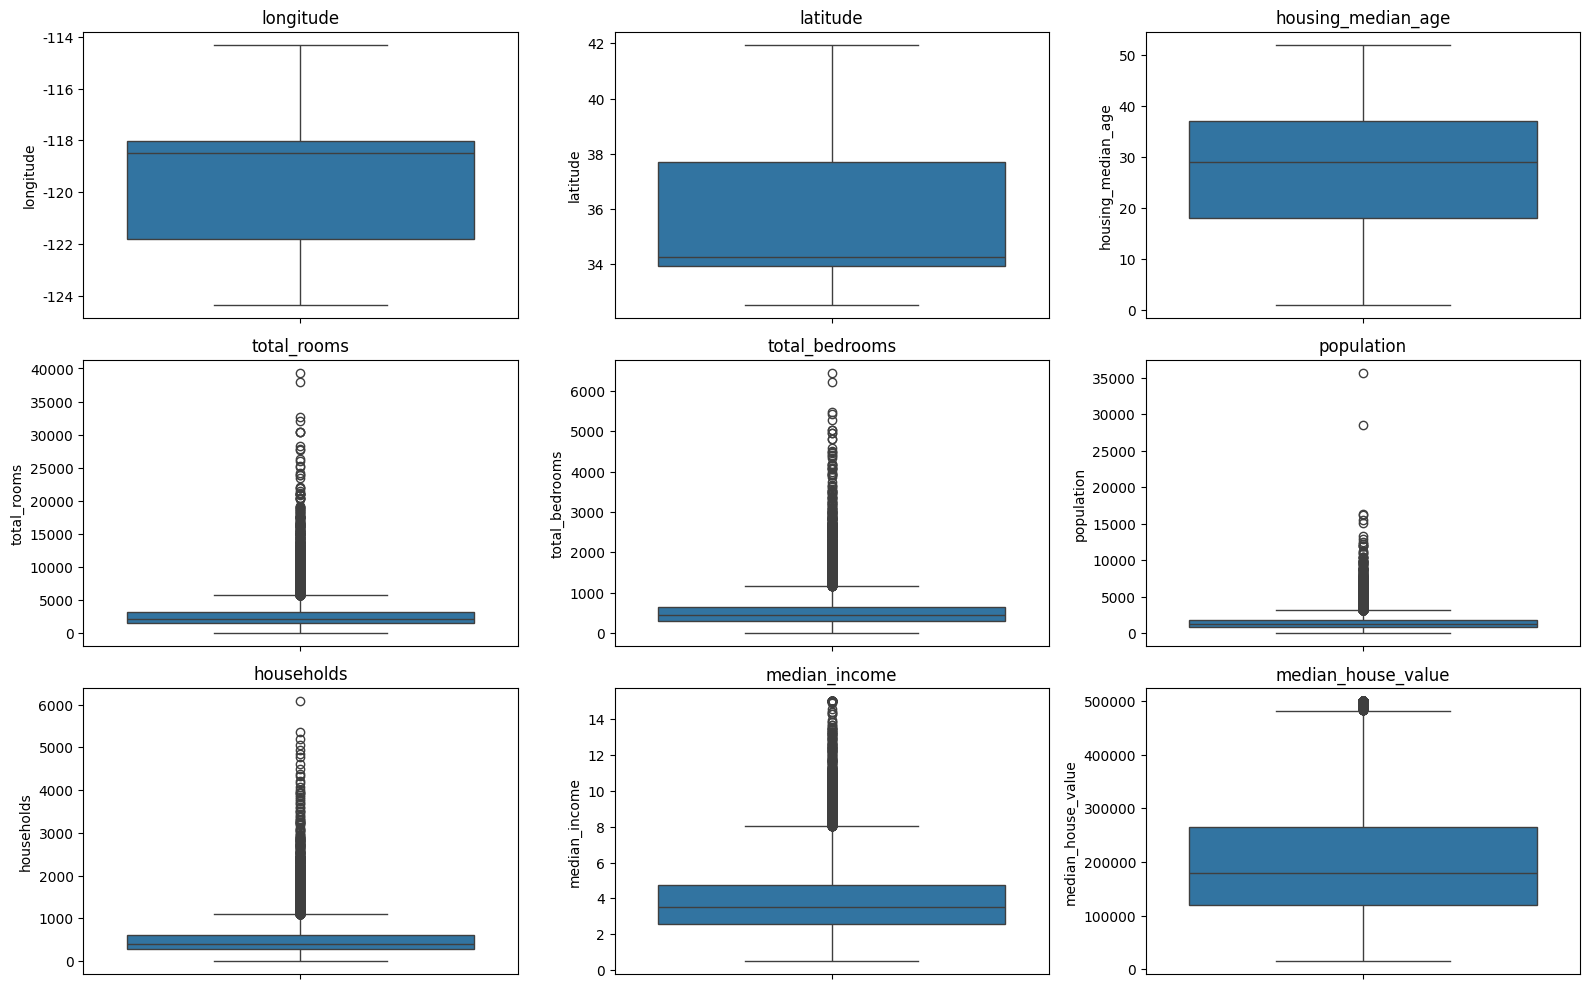

In [5]:
# 이상치들을 시각적으로 확인하는 방법
cols = df.select_dtypes(include=['number']).columns   # 수치형 컬럼들만 별도로 추림

plt.figure(figsize=(16, 10))
for i, col in enumerate(cols):
    plt.subplot(3, 3, i+1)
    sns.boxplot(data=df, y=df[col])
    plt.title(col)
    
plt.tight_layout()
plt.show()

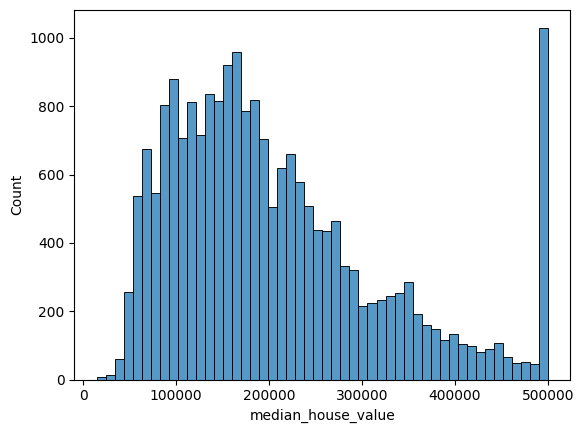

In [6]:
#sns.histplot(data=df['median_house_value'], bins=50)
sns.histplot(data=df, x='median_house_value', bins=50)
plt.show()

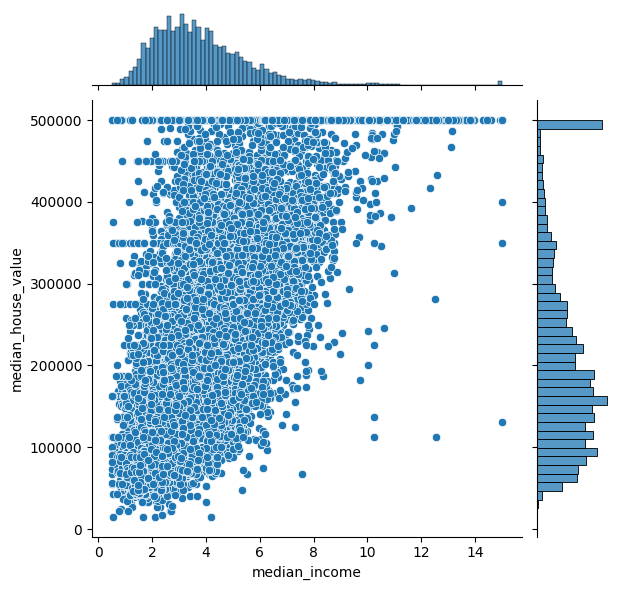

In [7]:
sns.jointplot(data=df, x='median_income', y='median_house_value')
plt.show()

In [8]:
s = pd.Series(np.arange(1, 11))
s

0     1
1     2
2     3
3     4
4     5
5     6
6     7
7     8
8     9
9    10
dtype: int64

In [9]:
s.describe()

count    10.00000
mean      5.50000
std       3.02765
min       1.00000
25%       3.25000
50%       5.50000
75%       7.75000
max      10.00000
dtype: float64

In [10]:
Q1 = s.quantile(0.25)
print(f'Q1: {Q1}')

Q3 = s.quantile(0.75)
print(f'Q3: {Q3}')

Q1: 3.25
Q3: 7.75


In [11]:
q1 = df['median_house_value'].quantile(0.25)
print(q1)

q3 = df['median_house_value'].quantile(0.75)
print(q3)

df['median_house_value'].describe()

119600.0
264725.0


count     20640.000000
mean     206855.816909
std      115395.615874
min       14999.000000
25%      119600.000000
50%      179700.000000
75%      264725.000000
max      500001.000000
Name: median_house_value, dtype: float64

In [12]:
IQR = q3 - q1
print(f'IQR = {IQR}')

IQR = 145125.0


In [13]:
# Upper bound 와 Lower Bound의 값 구하기

# Lower bound = Q1 - 1.5 * IQR
# Upper bound = Q3 + 1.5 * IQR

lb = q1 - 1.5 * IQR
ub = q3 + 1.5 * IQR
print(lb, ub)

-98087.5 482412.5


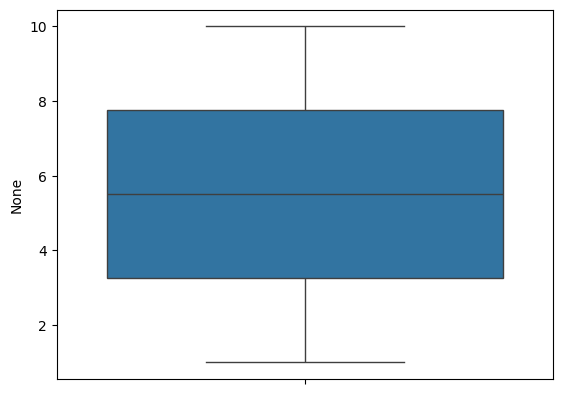

In [14]:
sns.boxplot(y=s)
plt.show()

In [15]:
Q1 = df['median_house_value'].quantile(0.25)
Q3 = df['median_house_value'].quantile(0.75)
IQR = Q3 - Q1

lb = Q1 - 1.5 * IQR
ub = Q3 + 1.5 * IQR

min = df['median_house_value'].min()

print(f'Upper Bound: {ub}, Lower Bound: {lb}')
print(f'Minimum value: {min}')

Upper Bound: 482412.5, Lower Bound: -98087.5
Minimum value: 14999.0


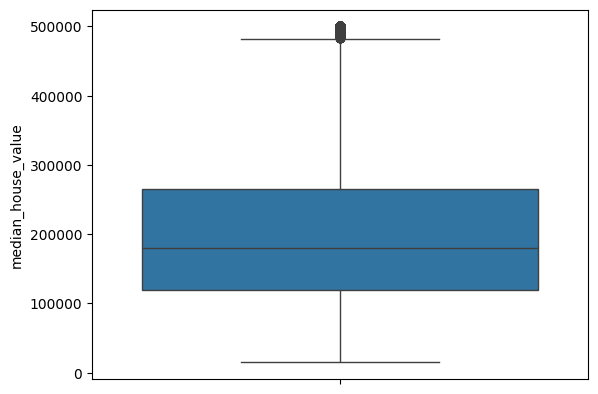

In [16]:
# 박스 플롯에서 상한선: 이상치 값이 있으면 Upper Bound, 이상치가 없으면 max
# 박스 플롯에서 하한선: 이상치 값이 있으면 Lower Bound, 이상치가 없으면 min
sns.boxplot(y=df['median_house_value'])
plt.show()

In [17]:
df_copy = df.drop('population', axis=1)
df_copy.head(3)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,177.0,7.2574,352100.0,NEAR BAY


In [18]:
# median_house_value에서 이상치가 존재하는 행들을 추출하기

cond = (df['median_house_value'] > ub) | (df['median_house_value'] < lb)
df[cond]['median_house_value']

89       500001.0
140      483300.0
459      500001.0
489      489600.0
493      500001.0
           ...   
20422    500001.0
20426    500001.0
20427    500001.0
20436    500001.0
20443    500001.0
Name: median_house_value, Length: 1071, dtype: float64

In [19]:
df_iqr = df[cond]
df_iqr.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
89,-122.27,37.80,52.0,249.0,78.0,396.0,85.0,1.2434,500001.0,NEAR BAY
140,-122.18,37.81,30.0,292.0,38.0,126.0,52.0,6.3624,483300.0,NEAR BAY
459,-122.25,37.87,52.0,609.0,236.0,1349.0,250.0,1.1696,500001.0,NEAR BAY
489,-122.25,37.86,48.0,2153.0,517.0,1656.0,459.0,3.0417,489600.0,NEAR BAY
493,-122.24,37.86,52.0,1668.0,225.0,517.0,214.0,7.8521,500001.0,NEAR BAY


In [20]:
li = df_iqr.index.to_list()

df_drops = df.drop(li,  axis=0)
df_drops.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19569 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           19569 non-null  float64
 1   latitude            19569 non-null  float64
 2   housing_median_age  19569 non-null  float64
 3   total_rooms         19569 non-null  float64
 4   total_bedrooms      19369 non-null  float64
 5   population          19569 non-null  float64
 6   households          19569 non-null  float64
 7   median_income       19569 non-null  float64
 8   median_house_value  19569 non-null  float64
 9   ocean_proximity     19569 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [21]:
# 이상치 제거하기
df_drops = df[(df['median_house_value'] <= ub) & (df['median_house_value'] >= lb)]
df_drops.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19569 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           19569 non-null  float64
 1   latitude            19569 non-null  float64
 2   housing_median_age  19569 non-null  float64
 3   total_rooms         19569 non-null  float64
 4   total_bedrooms      19369 non-null  float64
 5   population          19569 non-null  float64
 6   households          19569 non-null  float64
 7   median_income       19569 non-null  float64
 8   median_house_value  19569 non-null  float64
 9   ocean_proximity     19569 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [22]:
# 상한값으로 대치하기

df_copy = df.copy()

df_copy['median_house_value'] = df_copy['median_house_value'].clip(lb, ub)
df_copy.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,205981.224976
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,113217.350152
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,482412.500000


In [23]:
df = pd.read_csv(r'data\flight.csv')
df.head()


,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [24]:
df = df.drop(['Unnamed: 0'], axis=1)


In [25]:
df.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [26]:
cols = df.select_dtypes(include=['number']).columns
cols

Index(['duration', 'days_left', 'price'], dtype='object')

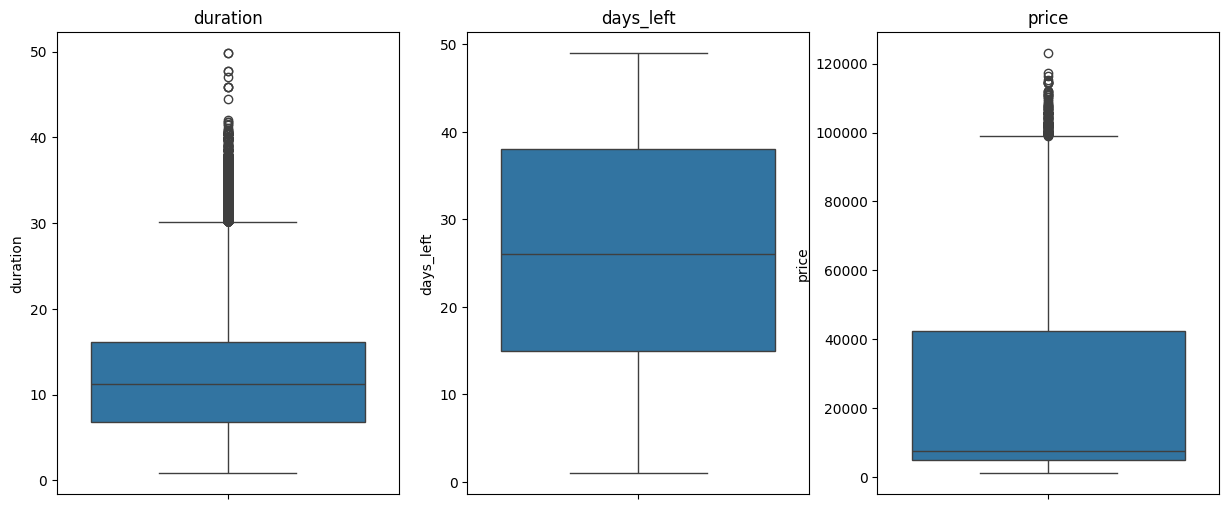

In [27]:
plt.figure(figsize=(15, 6))
for i, col in enumerate(cols):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
    
plt.show()

In [28]:
price_q1 = df['price'].quantile(0.25)
print(f'Q1: {price_q1}')
price_q3 = df['price'].quantile(0.75)
print(f'Q3: {price_q3}')
price_iqr = price_q3 - price_q1

price_ub = price_q3 + 1.5*price_iqr
price_lb = price_q1 - 1.5*price_iqr

print(f'IQR: {price_iqr}, ub: {price_ub}, lb: {price_lb}')

cond = (df['price'] > ub) | (df['price'] < lb)
print(type(cond))

Q1: 4783.0
Q3: 42521.0
IQR: 37738.0, ub: 99128.0, lb: -51824.0
<class 'pandas.core.series.Series'>


In [29]:
# 전처리
# 1. 결측치 처리
# 2. 이상치 처리
# 3. 인코딩(문자형 데이터를 수치형 데이터로 변환)
# 4. 스케일링(Standard, MinMaxScaling, RobustScaling)
# 5. 자르기(Splitting): 학습데이터 (훈련데이터)와 검증데이터로 분리하기